# Comparativa Avanzada: Detector de Energía CFAR vs Entropía CFAR

Este notebook aplica algoritmos modernos (CFAR + Morfología) tanto a la **potencia espectral (Energy Detector)** como a la **entropía espectral**. Incluye un espectrograma para visualizar la presencia real de la transmisión a baja SNR.

In [11]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import stft, medfilt
import scipy.ndimage as ndimage
import torch

# Añadir repo al path
repo_path = r"c:\repos\DroneDetectionRF\NoisyUAV"
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

from funciones.dataset.cargador import obtener_una_muestra, DATA_DIR
from funciones.dsp_rf.detector_entropia import detectar_bursts
from funciones.visualizacion.visualizacion import _ESTILO_PANEL

In [52]:
# ══════════════════════════════════════════════════════════════════════════════
#  PARÁMETROS DEL DETECTOR
# ══════════════════════════════════════════════════════════════════════════════
TARGET = 6       # 1 = DJI Mavic, 0 = DJI Phantom
SNR    = -14     # SNR Crítico
INDEX  = 17

FS                 = 14e6
NPERSEG            = 2048
Z_THRESH           = 3.0
MIN_BURST_MS       = 0.5
MERGE_GAP_MS       = 1.0
MIN_Z_ABS          = 4.0
BG_MULT            = 4.0
MAX_BINS_FRAC      = 0.25
SMOOTH_MS          = 0.2
ADAPTIVE_WINDOW_MS = 15.0  

OUT_FIG = r"c:\repos\DroneDetectionRF\TFM_documentos\figuras\ed_vs_entropy_cfar.pdf"
os.makedirs(os.path.dirname(OUT_FIG), exist_ok=True)

In [53]:
# 1. CARGA DE DATOS Y STFT
iq, target_id, snr_val, file_path = obtener_una_muestra(DATA_DIR, target=TARGET, snr=SNR, index=INDEX)

iq_np = iq.numpy()
if iq_np.ndim == 2 and iq_np.shape[0] == 2:
    iq_complex = iq_np[0] + 1j * iq_np[1]
else:
    iq_complex = iq_np

f_stft, t_sec, Zxx = stft(iq_complex, fs=FS, nperseg=NPERSEG, noverlap=NPERSEG//2, return_onesided=False)
f_stft = np.fft.fftshift(f_stft)
Zxx = np.fft.fftshift(Zxx, axes=0)
Sxx = np.abs(Zxx)**2
t_ms_stft = t_sec * 1000.0
dt_ms = t_ms_stft[1] - t_ms_stft[0]
print(f"Cargado: {file_path}\nResolución temporal: {dt_ms:.3f} ms/frame")

Cargado: -14
Resolución temporal: 0.073 ms/frame


In [54]:
# 2. DETECTOR DE ENERGÍA CON CFAR Y MORFOLOGÍA
P_frame = np.sum(Sxx, axis=0)

# Suavizado temporal equivalente
sigma_s = SMOOTH_MS / dt_ms
P_smooth = ndimage.gaussian_filter1d(P_frame, sigma_s)

# CFAR Local Noise Floor (Filtro Mediana)
w_adapt = int(ADAPTIVE_WINDOW_MS / dt_ms)
w_adapt = w_adapt if w_adapt % 2 != 0 else w_adapt + 1
P_local = medfilt(P_smooth, kernel_size=w_adapt)

# Dispersión Robusta (MAD)
mad_ed = np.median(np.abs(P_smooth - np.median(P_smooth)))
sigma_n_ed = 1.4826 * mad_ed

# Umbral CFAR para Potencia (Dispara hacia ARRIBA)
tau_ed = P_local + Z_THRESH * sigma_n_ed
mask_ed = P_smooth > tau_ed

# Morfología (Igual que entropía)
erode_frames = max(1, int(np.ceil(MIN_BURST_MS / dt_ms)))
dilate_frames = max(1, int(np.ceil(MERGE_GAP_MS / dt_ms)))
mask_ed = ndimage.binary_erosion(mask_ed, structure=np.ones(erode_frames))
mask_ed = ndimage.binary_dilation(mask_ed, structure=np.ones(dilate_frames))

labels_ed, num_ed = ndimage.label(mask_ed)
bursts_ed = [{'t0': t_ms_stft[np.where(labels_ed == i)[0][0]], 
              't1': t_ms_stft[np.where(labels_ed == i)[0][-1]]} 
             for i in range(1, num_ed + 1)]

print(f"Saltos detectados por Energía CFAR: {len(bursts_ed)}")

Saltos detectados por Energía CFAR: 2


In [55]:
# 3. DETECTOR DE ENTROPÍA (Pipeline TFM)
t_ms_ent, H, H_smooth, umbral_v, nf_v, ns, n_active, bursts_ent = detectar_bursts(
    iq, fs=FS, nperseg=NPERSEG, z_thresh=Z_THRESH,
    min_burst_ms=MIN_BURST_MS, merge_gap_ms=MERGE_GAP_MS,
    min_z_abs=MIN_Z_ABS, bg_mult=BG_MULT, max_bins_frac=MAX_BINS_FRAC,
    smooth_ms=SMOOTH_MS, adaptive_window_ms=ADAPTIVE_WINDOW_MS
)
print(f"Saltos detectados por Entropía CFAR: {len(bursts_ent)}")

Saltos detectados por Entropía CFAR: 5


C:\Users\Manuel\AppData\Local\Temp\ipykernel_19176\4212526926.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


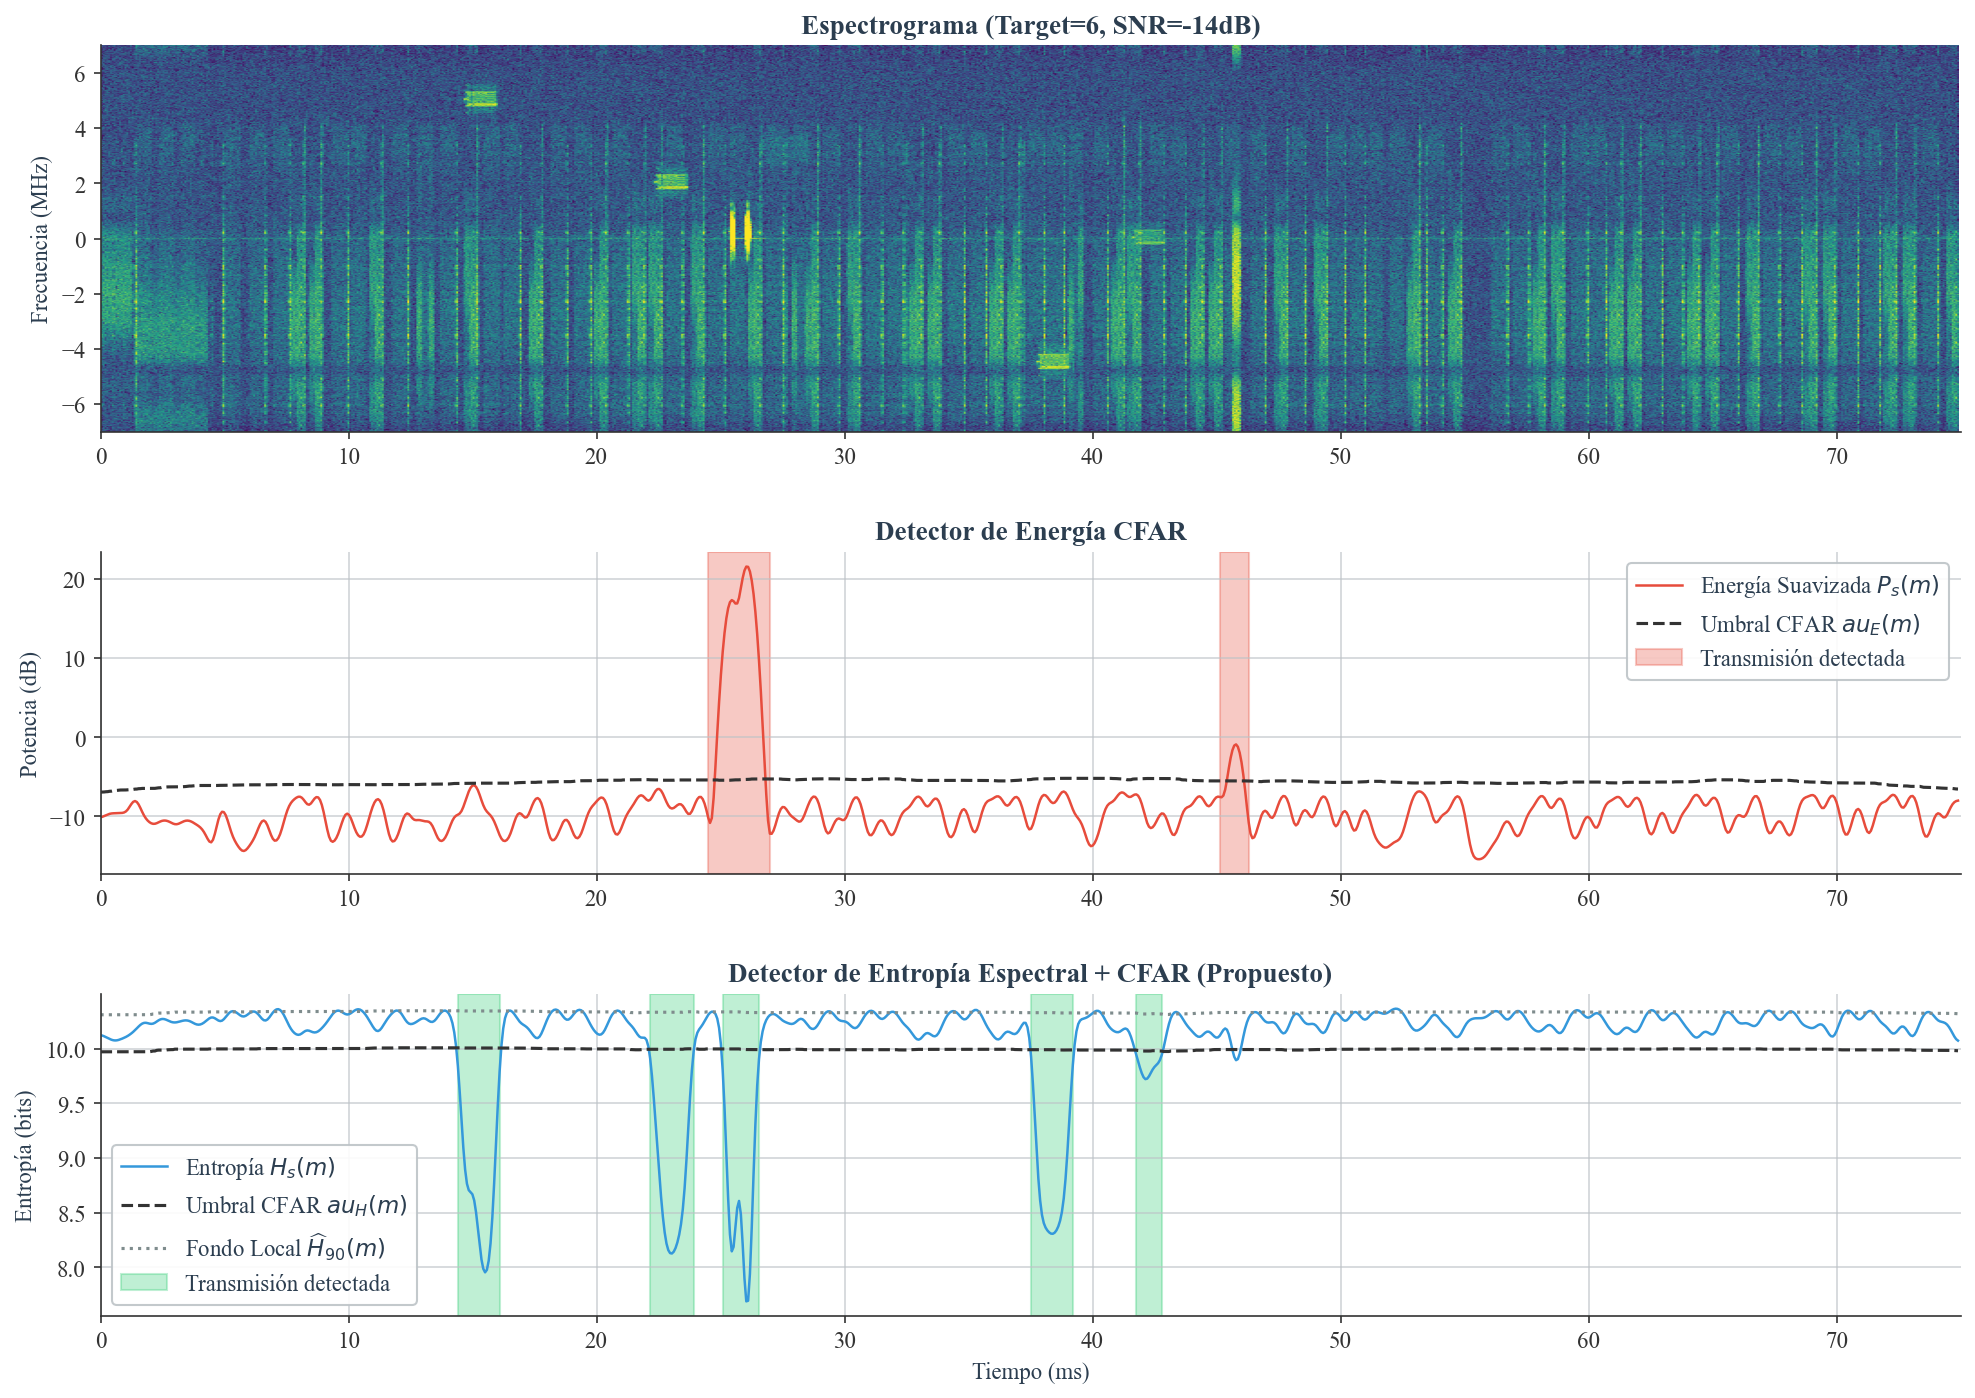


Figura guardada en: c:\repos\DroneDetectionRF\TFM_documentos\figuras\ed_vs_entropy_cfar.pdf


In [57]:
# 4. PLOT 3 PANELES (Espectrograma, Energía CFAR, Entropía CFAR)
plt.rcParams.update(_ESTILO_PANEL)

fig = plt.figure(figsize=(16, 11))
gs = gridspec.GridSpec(3, 1, height_ratios=[1.2, 1, 1], hspace=0.35)

# ---- PANEL 1: ESPECTROGRAMA ----
ax1 = plt.subplot(gs[0])
vmin = np.percentile(10 * np.log10(Sxx + 1e-12), 5)
vmax = np.percentile(10 * np.log10(Sxx + 1e-12), 99.9)
im = ax1.imshow(10 * np.log10(Sxx + 1e-12), aspect='auto', origin='lower',
                extent=[t_ms_stft[0], t_ms_stft[-1], f_stft[0]/1e6, f_stft[-1]/1e6],
                cmap='viridis', vmin=vmin, vmax=vmax)
ax1.set_title(f'Espectrograma (Target={TARGET}, SNR={SNR}dB)')
ax1.set_ylabel('Frecuencia (MHz)')
ax1.set_xlim([0, 75])

# ---- PANEL 2: ENERGÍA CFAR ----
ax2 = plt.subplot(gs[1], sharex=ax1)
P_smooth_db = 10 * np.log10(P_smooth + 1e-12)
tau_ed_db = 10 * np.log10(tau_ed + 1e-12)
ax2.plot(t_ms_stft, P_smooth_db, color='#e74c3c', label='Energía Suavizada $P_s(m)$', linewidth=1.2)
ax2.plot(t_ms_stft, tau_ed_db, color='#333333', linestyle='--', label='Umbral CFAR $\tau_E(m)$')

for b in bursts_ed:
    ax2.axvspan(b['t0'], b['t1'], color='#e74c3c', alpha=0.3, label='Transmisión detectada')
ax2.set_title('Detector de Energía CFAR')
ax2.set_ylabel('Potencia (dB)')
ax2.grid(True)
handles2, labels2 = ax2.get_legend_handles_labels()
by_label2 = dict(zip(labels2, handles2))
ax2.legend(by_label2.values(), by_label2.keys(), loc='best', framealpha=0.9)

# ---- PANEL 3: ENTROPÍA CFAR ----
ax3 = plt.subplot(gs[2], sharex=ax1)
ax3.plot(t_ms_ent, H_smooth, color='#3498db', label='Entropía $H_s(m)$', linewidth=1.2)
ax3.plot(t_ms_ent, umbral_v, color='#333333', linestyle='--', label='Umbral CFAR $\tau_H(m)$')
ax3.plot(t_ms_ent, nf_v, color='#7f8c8d', linestyle=':', label='Fondo Local $\widehat{H}_{90}(m)$')

for b in bursts_ent:
    ax3.axvspan(b['t0'], b['t1'], color='#2ecc71', alpha=0.3, label='Transmisión detectada')
ax3.set_title('Detector de Entropía Espectral + CFAR (Propuesto)')
ax3.set_xlabel('Tiempo (ms)')
ax3.set_ylabel('Entropía (bits)')
ax3.grid(True)
handles3, labels3 = ax3.get_legend_handles_labels()
by_label3 = dict(zip(labels3, handles3))
ax3.legend(by_label3.values(), by_label3.keys(), loc='best', framealpha=0.9)

plt.tight_layout()
plt.show()
fig.savefig(OUT_FIG, bbox_inches='tight')
print(f"\nFigura guardada en: {OUT_FIG}")